<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>


# Laboratorium nr 8: RNN - przykład generowanie tekstu.

## Import bibliotek

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)

2026-03-25 11:45:20.966865: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 11:45:21.020365: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-25 11:45:21.907071: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Numpy version: 2.4.2
Tensorflow version: 2.20.0


## Wczytanie przykładowego tekstu
Jak przykładowy tekst wykorzystamy tekst książki S. Lema: Eden. Plik `lem_stanislaw_eden.txt` do pobrania na platformie elf.

In [ ]:
with open("lem_stanislaw_eden.txt", "r") as f:
    text = f.read().lower()

print("Dlugość tekstu: {} znaków".format(len(text)))

Dlugość tekstu: 480564 znaków


Przykładowy fragment:

In [3]:
from pprint import pprint

In [4]:
print(text[:600], "...")


stanisław lem

eden



i

w obliczeniach był błąd. nie przeszli nad atmosferą, ale zderzyli się z nią. statek wbijał się w powietrze z grzmotem, od którego puchły bębenki. rozpłaszczeni na legowiskach czuli dobijanie amortyzatorów, przednie ekrany zaszły płomieniem i zgasły, poduszka rozżarzonych gazów, napierająca na dziób, zatopiła zewnętrzne obiektywy, hamowanie było niedostateczne i opóźnione. sterownię napełnił swąd rozgrzanej gumy, pod prasą deceleracji ślepli i głuchli, to był koniec, ale nawet tego nie mógł żaden pomyśleć, nie starczyło wszystkich sił, aby unieść klatkę piersiową, wci ...


## Podział na część trenującą i testową

In [ ]:
text = text.replace("\n", " ")
split = int(0.9 * len(text))
train_text = text[:split]
test_text = text[split:]

## Tworzenie słwonika znaków

In [ ]:
vocab = sorted(set(text))
print("{} unikalnych znaków".format(len(vocab)))

58 unikalnych znaków


Rozkład znaków w tekście

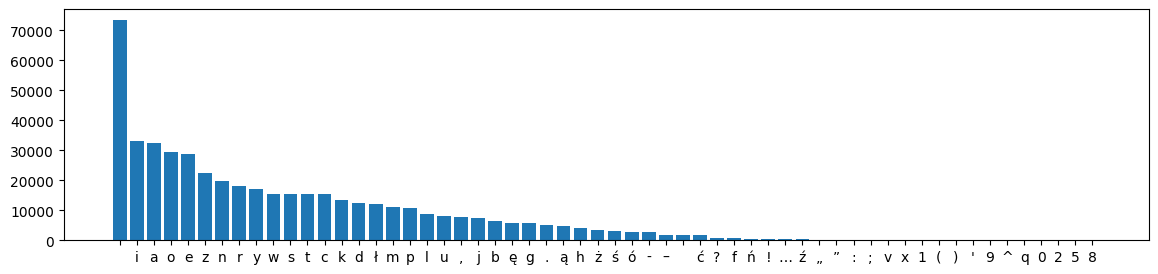

In [7]:
from collections import Counter

counter = Counter(text)
chars, counts = zip(*counter.most_common())
indices = np.arange(len(counts))


plt.figure(figsize=(14, 3))
plt.bar(indices, counts, 0.8)
plt.xticks(indices, [c for c in chars])
plt.show()

### Reprezentacja wektorowa
Każdemu ze znaków możemy przypisać jakąś liczbe i w ten sposób zakodować tekst w postaci numerycznej. Aby łatwo przechodzić z postaci numerycznej na tekstową i odwrotnie stwórzmy sobie pomocnicze słowniki:

In [8]:
char_indices = dict((c, i) for i, c in enumerate(vocab))
indices_char = dict((i, c) for i, c in enumerate(vocab))

### Generowanie sekwencji uczących
Będziemy tworzyć prosty model języka naturalnego, czyli model, który będzie generował kolejny znak na bazie wcześniejszej sekwencji znaków.

In [ ]:
def make_sequences(text, max_length=40, step=3):
    sequences = []
    next_chars = []
    for i in range(0, len(text) - max_length, step):
        sequences.append(text[i : i + max_length])
        next_chars.append(text[i + max_length])
    return sequences, next_chars


sequences, next_chars = make_sequences(train_text)
sequences_test, next_chars_test = make_sequences(test_text, step=10)

print("nb train sequences:", len(sequences))
print("nb test sequences:", len(sequences_test))

nb train sequences: 144156
nb test sequences: 4802


Wymieszenia sekwencji aby nie podawać obok siebie sekwencji zawierających podobne sekwencje znaków:

In [ ]:
from sklearn.utils import shuffle

sequences, next_chars = shuffle(sequences, next_chars, random_state=30)

Przykładowa sekwencja:

In [11]:
sequences[0]

'ężarowym włazie. musimy wyjść tym - jeże'

Kolejny znak to:

In [12]:
next_chars[0]

'l'

### Kodowanie one-hot
W modelu wykorzystamy proste kodowanie one-hot

In [13]:
max_length = 40
n_sequences = len(sequences)
n_sequences_test = len(sequences_test)
voc_size = len(vocab)

X = np.zeros((n_sequences, max_length, voc_size), dtype=np.float32)
y = np.zeros((n_sequences, voc_size), dtype=np.float32)

X_test = np.zeros((n_sequences_test, max_length, voc_size), dtype=np.float32)
y_test = np.zeros((n_sequences_test, voc_size), dtype=np.float32)

for i, sequence in enumerate(sequences):
    for t, char in enumerate(sequence):
        X[i, t, char_indices[char]] = 1
    y[i, char_indices[next_chars[i]]] = 1

for i, sequence in enumerate(sequences_test):
    for t, char in enumerate(sequence):
        X_test[i, t, char_indices[char]] = 1
    y_test[i, char_indices[next_chars_test[i]]] = 1

In [14]:
X.shape, y.shape

((144156, 40, 58), (144156, 58))

## Ćwiczenie 1:
### Model sieci rekurencyjnej
Stwórz model rekurencyjnej sieci neuronowej do prognozowania następnego znaku w sekwencji. Pamiętaj, że zakodowaliśmy znaki za pomocą metody one-hot.

In [15]:
from tensorflow import keras

In [16]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding

In [ ]:
# twój model tutaj
vocab_size = 58
rnn_units = 128

x = Input(shape=(40, vocab_size))
l = LSTM(128, return_sequences=True)(x)
l = LSTM(128)(l)
o = Dense(voc_size, activation="softmax")(l)

model = Model(inputs=x, outputs=o)

model.summary()

I0000 00:00:1774435524.575330    1701 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9558 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:02:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 58)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 40, 128)        │        95,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 58)             │         7,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,810 (917.23 KB)

 Trainable params: 234,810 (917.23 KB)

 Non-trainable params: 0 (0.00 B)

## Miara jakości prawdopodobieństwa
Do sprawdzenia czy model dobrze uczy się prawdopodobieńst kolejnego znaku można wykorzystać miarę [Perplexity](https://en.wikipedia.org/wiki/Perplexity)

In [18]:
def perplexity(y_true, y_pred):
    """
    y_true is one-hot encoded ground truth.
    y_pred is predicted likelihoods for each class.
    2 ** -mean(log2(p))
    """
    likelihoods = np.sum(y_pred * y_true, axis=1)
    return 2 ** -np.mean(np.log2(likelihoods))

Perplexity losowo zaicjalizowanego modelu

In [19]:
def model_perplexity(model, X, y, verbose=0):
    predictions = model.predict(X, verbose=verbose)
    return perplexity(y, predictions)

In [20]:
model_perplexity(model, X_test, y_test)

2026-03-25 11:45:25.663228: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


np.float32(57.921963)

### Uczenie modelu na małym podzbiorze zbioru trenującego
Przed rozpoczęciem uczenia upewnij się że masz uruchomione środowiesko wyposarzone w GPU inaczej będzie trzeba poczekać dłuższą chwile.

In [ ]:
from keras.optimizers import Adam

model.compile(optimizer=Adam(), loss="categorical_crossentropy")

In [22]:
small_train = slice(0, None, 40)
hist = model.fit(X[small_train], y[small_train], batch_size=128, epochs=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5510


Perplexity po krótkim uczeniu:

In [23]:
model_perplexity(model, X_test, y_test)

np.float32(27.41144)

Powinno być mniejsze niż poprzednio inaczej model niczego sie nie nauczył.

## Generowanie losowej próbki tekstu z modelu
Generujemy rekurencyjnie znak po znaku poprzez losowanie z odpowiednim prawdopodobieństwem

$$
p_{\theta}(c_n | c_{n-1}, c_{n-2}, \ldots, c_0) \cdot p_{\theta}(c_{n-1} | c_{n-2}, \ldots, c_0) \cdot \ldots \cdot p_{\theta}(c_{0})
$$

Parametr 'temperature' pozwala na usunięcie dodatkowej entropi z modelu.

#### Ćwiczenie 2:
Poniżej znajduje się kod generujący przykładowy tekst, spróbuj w prostych słowach opisać co i jak on tak na prawdę robi.

_Zapisz swoją odpowiedź w tej komórce_

In [ ]:
def sample_one(preds, temperature=1.0):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probs = np.random.multinomial(1, preds, size=1)
    return np.argmax(probs)


def generate_text(model, seed_string, length=50, temperature=1.0):
    generated = seed_string
    prefix = seed_string

    for i in range(length):
        # Vectorize prefix string to feed as input to the model:
        x = np.zeros((1, max_length, voc_size))
        shift = max_length - len(prefix)
        for t, char in enumerate(prefix):
            x[0, t + shift, char_indices[char]] = 1.0

        preds = model.predict(x, verbose=0)[0]
        next_index = sample_one(preds, temperature)
        next_char = indices_char[next_index]

        generated += next_char
        prefix = prefix[1:] + next_char
    return generated

Przykład:

In [ ]:
generate_text(model, "statek wbijał się ", temperature=0.1)

'statek wbijał się                                        e          '

In [ ]:
generate_text(model, "statek wbijał się ", temperature=0.8)

'statek wbijał się emnyałw łacntzcbwołr  oetanc n  emo  wł  i yyaęaę '

## Dalsze trenowanie
Wygenerowany poprzednio tekst, nie wygląda zbyt "czytelnie" a to dla tego, że model uczony był zbyt krótki i na niewielkim zbiorze danych. Pouczmy go więc dłużej. Wykonuj poniższą komórkę tyle razy aż generowane sekwencjie będą miały sens.

In [ ]:
nb_epoch = 5
seed_strings = ["dziś jest wtorek "]

for epoch in range(nb_epoch):
    print("# Epoch {}/{}".format(epoch + 1, nb_epoch))
    model.fit(X, y, validation_split=0.1, batch_size=128, epochs=1, verbose=1)
    test_perplexity = model_perplexity(model, X_test, y_test)
    print("Perplexity na zbiorze testowym: {}".format(test_perplexity))

    for temperature in [0.1, 0.5, 1]:
        print("Przykładowy tekst dla temperatury {}:\n".format(temperature))
        for seed_string in seed_strings:
            print(generate_text(model, seed_string, temperature=temperature))
            print()

# Epoch 1/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 2.7380 - val_loss: 2.3780
Perplexity na zbiorze testowym: 11.774773597717285
Przykładowy tekst dla temperatury 0.1:

dziś jest wtorek wierzy przew porze nie nie z powiedzie nie nie wie

Przykładowy tekst dla temperatury 0.5:

dziś jest wtorek rodznie czych powiedmi nie w wakiad się połe tor w

Przykładowy tekst dla temperatury 1:

dziś jest wtorek śnie z, niebny!  b zzali znotcz bu się mnaj,  rypo

# Epoch 2/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 2.2868 - val_loss: 2.1896
Perplexity na zbiorze testowym: 9.704578399658203
Przykładowy tekst dla temperatury 0.1:

dziś jest wtorek w przednie w przedzie w powiedzie w przed powiedzi

Przykładowy tekst dla temperatury 0.5:

dziś jest wtorek walimi. godroski, do wiedziej przejnech się z zara

Przykładowy tekst dla temperatury 1:

dziś jest wtorek waduć dlów.  cebaca przekiach. ?cszyka iamkiecega.

# Epoch 3/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 2.

## Ćwiczenie 3
Rozbuduj model sieci neuronowej z wykorzystaniem warstwy Embedding, zastępując nią kodowanie one-hot. Zwizualizowac warstwe emmbeding.

In [28]:
max_length = 40
n_sequences = len(sequences)
n_sequences_test = len(sequences_test)
voc_size = len(vocab)

X = np.zeros((n_sequences, max_length), dtype=np.int32)
y = np.zeros((n_sequences,), dtype=np.int32)

X_test = np.zeros((n_sequences_test, max_length), dtype=np.int32)
y_test = np.zeros((n_sequences_test,), dtype=np.int32)

for i, sequence in enumerate(sequences):
    for t, char in enumerate(sequence):
        X[i, t] = char_indices[char]
    y[i] = char_indices[next_chars[i]]

for i, sequence in enumerate(sequences_test):
    for t, char in enumerate(sequence):
        X_test[i, t] = char_indices[char]
    y_test[i] = char_indices[next_chars_test[i]]

In [29]:
# model z warstwą Embedding zamiast one-hot
embedding_dim = 64

inp = Input(shape=(max_length,), dtype="int32")  # sekwencja indeksów znaków
emb = Embedding(input_dim=voc_size, output_dim=embedding_dim, input_length=max_length)(
    inp
)  # (None, 40, embedding_dim)

l = LSTM(rnn_units, return_sequences=True)(emb)
l = LSTM(rnn_units)(l)
out = Dense(voc_size, activation="softmax")(l)

model = Model(inputs=inp, outputs=out)
model.summary()

/home/qertal/miniconda3/envs/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 40, 64)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 40, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 58)             │         7,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,594 (943.73 KB)

 Trainable params: 241,594 (943.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def perplexity(y_true, y_pred, eps=1e-12):
    likelihoods = np.sum(y_pred * y_true, axis=1)
    likelihoods = np.clip(likelihoods, eps, 1.0)
    return np.exp(-np.mean(np.log(likelihoods)))


def perplexity_sparse(y_true, y_pred, eps=1e-12):
    likelihoods = y_pred[np.arange(len(y_true)), y_true]
    likelihoods = np.clip(likelihoods, eps, 1.0)
    return np.exp(-np.mean(np.log(likelihoods)))


def model_perplexity(model, X, y_true, verbose=0):
    preds = model.predict(X, verbose=verbose)
    return perplexity_sparse(y_true, preds)


def model_perplexity_embedding(model, X_int, y_one_hot, verbose=0):
    preds = model.predict(X_int, verbose=verbose)
    return perplexity(y_one_hot, preds)

In [ ]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [32]:
pp_test = model_perplexity(model, X_test, y_test)
print("Test perplexity:", pp_test)

Test perplexity: 57.990368


In [37]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model

embedding_dim = 64
rnn_units = 128

inp = Input(shape=(max_length,), dtype="int32")
emb = Embedding(input_dim=voc_size, output_dim=embedding_dim)(inp)

x = LSTM(rnn_units, return_sequences=True)(emb)
x = LSTM(rnn_units)(x)
out = Dense(voc_size, activation="softmax")(x)

model = Model(inputs=inp, outputs=out)

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

# history = model.fit(
#     X,
#     y,
#     validation_data=(X_test, y_test),
#     epochs=5,
#     batch_size=128
# )

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 40, 64)         │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 40, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 58)             │         7,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,594 (943.73 KB)

 Trainable params: 241,594 (943.73 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
from keras.callbacks import Callback
import numpy as np


class TextGeneratorCallback(Callback):
    def __init__(
        self,
        seed_text,
        char_indices,
        indices_char,
        max_length,
        temperatures=[0.2, 0.5, 1.0],
        gen_length=80,
    ):
        super().__init__()
        self.seed_text = seed_text
        self.char_indices = char_indices
        self.indices_char = indices_char
        self.max_length = max_length
        self.temperatures = temperatures
        self.gen_length = gen_length

    def sample_with_temperature(self, preds, temperature=1.0):
        preds = np.asarray(preds).astype("float64")
        preds = np.log(np.clip(preds, 1e-12, 1.0)) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        return np.random.choice(len(preds), p=preds)

    def generate_text(self, temperature):
        generated = self.seed_text
        sentence = self.seed_text[-self.max_length :]

        for _ in range(self.gen_length):
            x_pred = np.zeros((1, self.max_length), dtype=np.int32)
            for t, char in enumerate(sentence):
                x_pred[0, t] = self.char_indices[char]

            preds = self.model.predict(x_pred, verbose=0)[0]
            next_index = self.sample_with_temperature(preds, temperature)
            next_char = self.indices_char[next_index]

            generated += next_char
            sentence = generated[-self.max_length :]

        return generated

    def on_epoch_end(self, epoch, logs=None):
        print(f"\nEpoka {epoch+1}")
        for temp in self.temperatures:
            print(f"\nTemperatura {temp}:")
            print(self.generate_text(temp))

In [40]:
seed_text = "dziś jest wtorek".lower()
seed_text = seed_text[:max_length].rjust(max_length)

text_callback = TextGeneratorCallback(
    seed_text=seed_text,
    char_indices=char_indices,
    indices_char=indices_char,
    max_length=max_length,
    temperatures=[0.1, 0.5, 1.0],
    gen_length=80,
)

history = model.fit(
    X,
    y,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=128,
    callbacks=[text_callback],
)

Epoch 1/15
 841/1127 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step - accuracy: 0.2077 - loss: 2.8928  
Epoka 1

Temperatura 0.1:
                        dziś jest wtorek podzierzie podzierzie podzierzie wastoro wasty wadzie się się podzierzie podzie

Temperatura 0.5:
                        dziś jest wtorek opadzera warócz postoszeniej to tzew podkiecziego powierziektor tak odla ta sie

Temperatura 1.0:
                        dziś jest wtorekrhuniał roczyd pyoow włók cho dłny zażęda.,  – jegdoć - ppłyrpyli  władła mnądto
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.2699 - loss: 2.5847 - val_accuracy: 0.3155 - val_loss: 2.3865
Epoch 2/15
1106/1127 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3406 - loss: 2.2614 
Epoka 2

Temperatura 0.1:
                        dziś jest wtorek w ter się się się się się powiedział się się powiedział się na powiedział się n

Temperatura 0.5:
                        dziś jest wtorek to się na te chymi, zażerzenie prodrzestem te miemia się po stopie